In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import os
import cv2
import random

In [2]:
train_dir = "/Users/daljeetdhillon/Desktop/pp/data/train"
val_dir   = "/Users/daljeetdhillon/Desktop/pp/data/val"
test_dir  = "/Users/daljeetdhillon/Desktop/pp/data/test"

In [3]:
img_size = (224, 224)
batch_size = 32

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Validation/Test (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [5]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model initially
base_model.trainable = False

In [6]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.6)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 639ms/step - accuracy: 0.4657 - loss: 1.0289 - val_accuracy: 0.6939 - val_loss: 0.6411 - learning_rate: 0.0010
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 583ms/step - accuracy: 0.5442 - loss: 0.7201 - val_accuracy: 0.6939 - val_loss: 0.6133 - learning_rate: 0.0010
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 609ms/step - accuracy: 0.5794 - loss: 0.7214 - val_accuracy: 0.7143 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 598ms/step - accuracy: 0.6358 - loss: 0.6333 - val_accuracy: 0.7653 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 0.5968 - loss: 0.6757 - val_accuracy: 0.7347 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 603ms/step - accuracy: 0.6197 - loss: 0.6541 - val_accuracy: 0.7347 - val_loss: 0.5897 - learning_rate: 0.0010
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 599ms/step - accuracy: 0.6087 - loss: 0.

In [10]:
# Unfreeze base model
base_model.trainable = True

# Freeze first layers, fine-tune deeper layers
for layer in base_model.layers[:50]:
    layer.trainable = False

In [11]:
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 847ms/step - accuracy: 0.6193 - loss: 0.6577 - val_accuracy: 0.7449 - val_loss: 0.5557 - learning_rate: 5.0000e-06
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 763ms/step - accuracy: 0.5934 - loss: 0.6582 - val_accuracy: 0.7347 - val_loss: 0.5558 - learning_rate: 5.0000e-06
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 805ms/step - accuracy: 0.6294 - loss: 0.6298 - val_accuracy: 0.7347 - val_loss: 0.5556 - learning_rate: 5.0000e-06
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 802ms/step - accuracy: 0.6336 - loss: 0.6542 - val_accuracy: 0.7347 - val_loss: 0.5541 - learning_rate: 5.0000e-06
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 808ms/step - accuracy: 0.6125 - loss: 0.6526 - val_accuracy: 0.7347 - val_loss: 0.5532 - learning_rate: 5.0000e-06
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 807ms/step - accuracy: 0.6770 - loss: 0.6140 - val_accuracy: 0.7347 - val_loss: 0.5529 - learning_rate: 5.0000e-06
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 830ms/step - acc

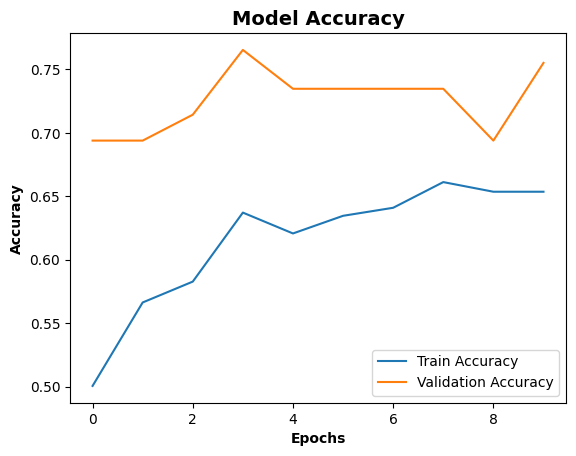

In [13]:

plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')

plt.legend()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.6543 - loss: 0.6173
Test Loss: 0.5675737261772156
Test Accuracy: 0.7400000095367432


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step


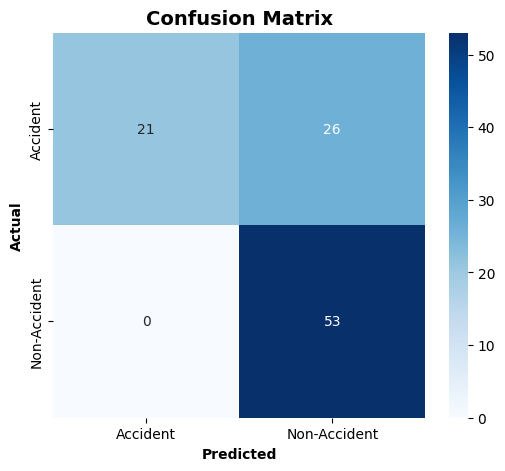

In [15]:

# Predictions
test_data.reset()
Y_true = test_data.classes
Y_pred_probs = model.predict(test_data)
Y_pred = (Y_pred_probs > 0.5).astype(int).reshape(-1)

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Accident','Non-Accident'],
            yticklabels=['Accident','Non-Accident'])

plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')

plt.show()

In [16]:
print(classification_report(
    Y_true,
    Y_pred,
    target_names=['Accident', 'Non-Accident']
))

              precision    recall  f1-score   support

    Accident       1.00      0.45      0.62        47
Non-Accident       0.67      1.00      0.80        53

    accuracy                           0.74       100
   macro avg       0.84      0.72      0.71       100
weighted avg       0.83      0.74      0.72       100



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
Image: test10_56.jpg
True Label : accident
Predicted  : Accident
Confidence : 64.99 %


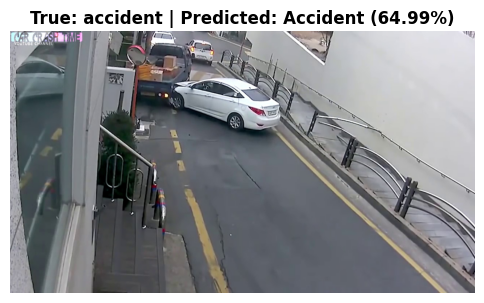

In [17]:

# Pick random class folder
folder = random.choice([
    os.path.join(test_dir, "accident"),
    os.path.join(test_dir, "non_accident")
])

true_label = folder.split("/")[-1]

# Random image
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

# Read image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (224,224)) / 255.0
img_input = np.expand_dims(img_resized, axis=0)

# Prediction
pred = model.predict(img_input)[0][0]

confidence = pred if pred > 0.5 else (1 - pred)
pred_label = "Non-Accident" if pred > 0.5 else "Accident"

print("Image:", img_name)
print("True Label :", true_label)
print("Predicted  :", pred_label)
print("Confidence :", round(confidence * 100, 2), "%")

# Display
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)

plt.title(
    f"True: {true_label} | Predicted: {pred_label} ({round(confidence*100,2)}%)",
    fontsize=12,
    fontweight='bold'
)

plt.axis("off")
plt.show()

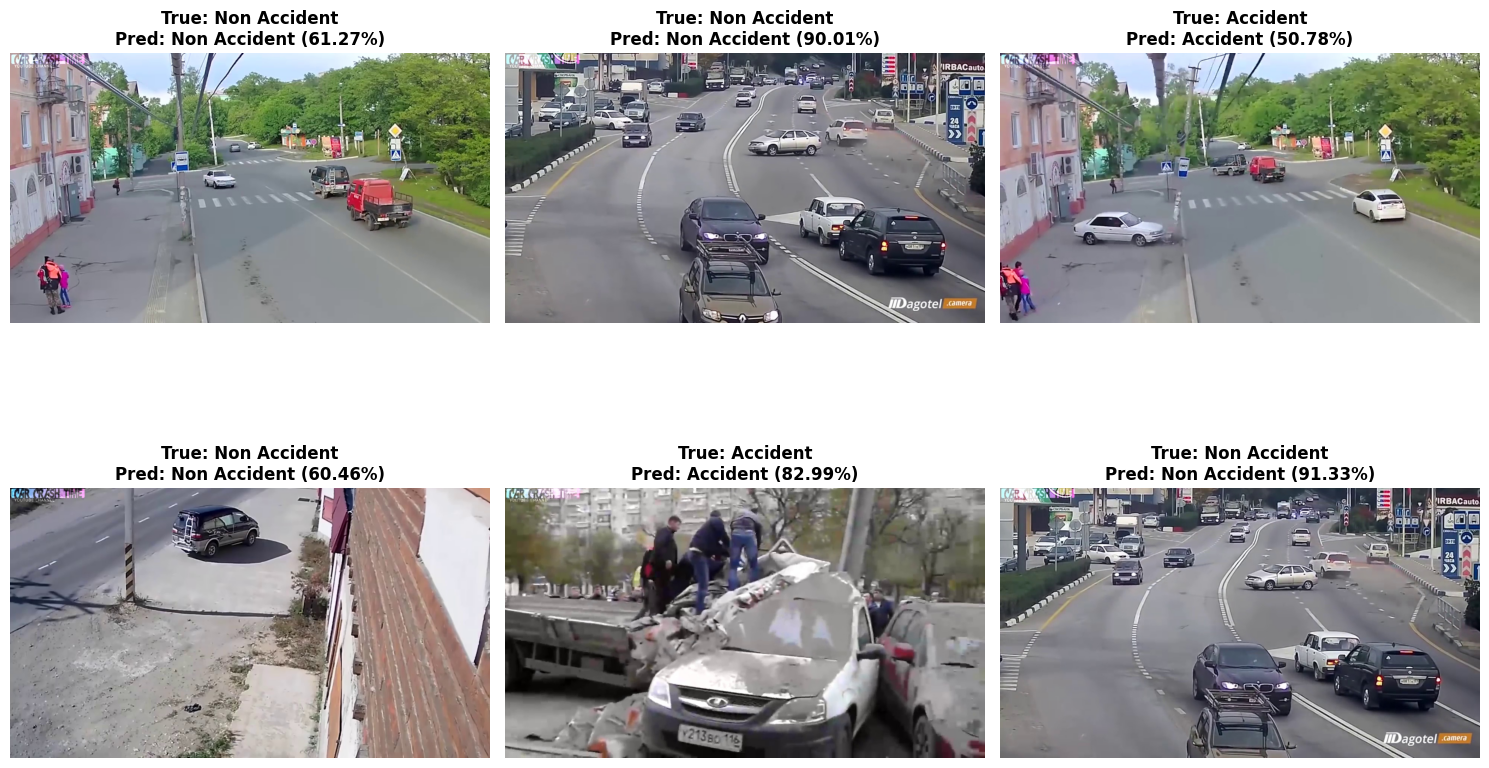

In [25]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

test_path = "/Users/daljeetdhillon/Desktop/pp/data/test"

# Correct folder names
classes = ["Accident", "Non Accident"]

num_images = 6
cols = 3
rows = math.ceil(num_images / cols)

plt.figure(figsize=(15, 5 * rows))

for i in range(num_images):

    # Pick class
    cls = random.choice(classes)
    folder = os.path.join(test_path, cls)

    # Safety check
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue

    images = os.listdir(folder)

    if len(images) == 0:
        print(f"No images in: {folder}")
        continue

    # Pick image
    img_name = random.choice(images)
    img_path = os.path.join(folder, img_name)

    # Read image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img_resized = cv2.resize(img_rgb, (224, 224)) / 255.0
    img_input = np.expand_dims(img_resized, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    confidence = pred if pred > 0.5 else (1 - pred)
    pred_label = "Non Accident" if pred > 0.5 else "Accident"

    # Plot
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)

    plt.title(
        f"True: {cls}\nPred: {pred_label} ({round(confidence*100,2)}%)",
        fontsize=12,
        fontweight='bold'
    )

    plt.axis("off")

plt.tight_layout()
plt.show()